                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Train shape: (460048, 14)
Test shape: (115013, 14)
[[111637      8]
 [   302   3066]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.

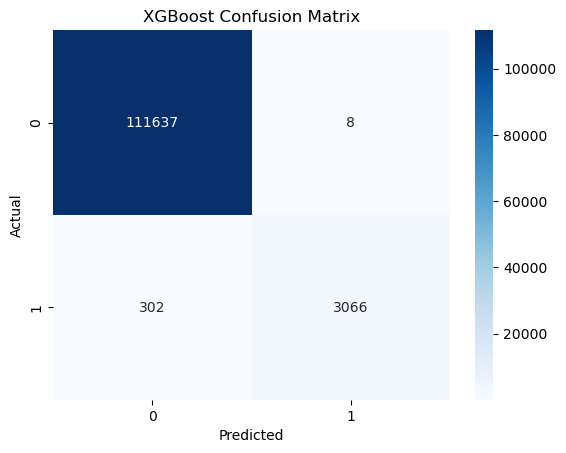

ROC-AUC: 0.9618056679164929


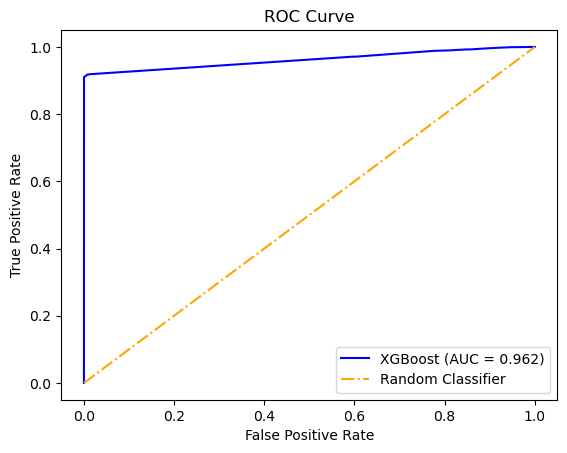

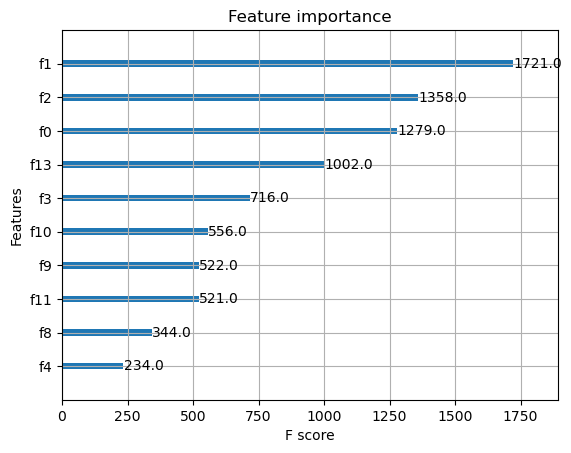

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Loading preprocessed data
df = pd.read_csv("processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

# Features and labels
x = df.drop(["BlockId","Label"], axis=1)
y = df["Label"]

# Remove weak features
selector = VarianceThreshold(threshold=0.01)
x = selector.fit_transform(x)

# Log transform
x = np.log1p(x)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# XGBoost Model
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,   # important for anomaly detection
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb.fit(x_train, y_train)

# Predictions
y_pred = xgb.predict(x_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

# Probability scores for ROC
y_prob = xgb.predict_proba(x_test)[:,1]

# AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='dashdot', color='orange', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

'''This shows which log events cause anomalies, which is extremely useful for your AI log monitoring project.'''
plot_importance(xgb, max_num_features=10)
plt.show()